# MMIS 671 homework 4: Classification using *TensorFlow* and *Keras*
We shall use *TensorFlow* and *Keras* to develop (1) a multilayered perceptron, and (2) a convolution neural network to recognize handwritten digits using 60,000 examples for training and 10,000 examples for testing obtained from the *Keras* *MNIST* data for digit recognition : https://keras.io/api/datasets/mnist/. Each example is a $28\times 28$ grayscale image labeled with a digit (0 through 9). 

## Import libraries

In [5]:
import numpy as np # for computation
import pandas as pd # for data handling and analysis
import matplotlib.pyplot as plt # for plotting

# metrics to evaluate models
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import plot_roc_curve

# import tensorFlow / keras for neural networks
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical # for one-hot representation
from tensorflow.keras.layers import Dense, Conv2D # dense and convolution layer
from tensorflow.keras.layers import Dropout, BatchNormalization # for regularization
from tensorflow.keras.layers import Flatten # to flatten convolution layer output
from tensorflow.keras.layers import MaxPooling2D # for max pooling
from tensorflow.keras.layers import Activation # for activation functions 
from tensorflow.keras.optimizers import SGD, Adam # for optimization
from tensorflow.keras.utils import plot_model # to display model
from tensorflow.keras.callbacks import ModelCheckpoint # to save best model
from tensorflow.keras.models import load_model # to load saved model

from keras.datasets import mnist # to import data for training and testing 

## Task 0: Get data
Read *MNIST* labeled image data for training and testing classifiers into *Numpy* arrays. Check the shape of the arrays and the distribution of digits in the training and test data.

In [3]:
# Read MNIST labeled image data for training and testing
(x_train, y_train), (x_test, y_test) = mnist.load_data() 

# Check shape of arrays
print('%d training and %d test examples read' %(len(y_train), len(y_test)))
print("Shape of arrays:")
print("\tTraining -> input x_train: %s, output y_train: %s" %(x_train.shape, y_train.shape))
print("\tTest -> input x_test: %s, output y_test: %s" %(x_test.shape, y_test.shape))
print()

# Check class distributions
print("Distribution of digits in training data:")
digits, counts = np.unique(y_train, return_counts=True)
print("Counts:")
print(pd.DataFrame(counts).T)
print("Proportions:")
print(pd.DataFrame((counts/counts.sum()).round(2)).T)
print()

print("Distribution of digits in test data:")
digits, counts = np.unique(y_test, return_counts=True)
print("Counts:")
print(pd.DataFrame(counts).T)
print("Proportions:")
print(pd.DataFrame((counts/counts.sum()).round(2)).T)

11493376/11490434 [==============================] - 0s 0us/step
60000 training and 10000 test examples read
Shape of arrays:
	Training -> input x_train: (60000, 28, 28), output y_train: (60000,)
	Test -> input x_test: (10000, 28, 28), output y_test: (10000,)

Distribution of digits in training data:
Counts:
      0     1     2     3     4     5     6     7     8     9
0  5923  6742  5958  6131  5842  5421  5918  6265  5851  5949
Proportions:
     0     1    2    3    4     5    6    7    8    9
0  0.1  0.11  0.1  0.1  0.1  0.09  0.1  0.1  0.1  0.1

Distribution of digits in test data:
Counts:
     0     1     2     3    4    5    6     7    8     9
0  980  1135  1032  1010  982  892  958  1028  974  1009
Proportions:
     0     1    2    3    4     5    6    7    8    9
0  0.1  0.11  0.1  0.1  0.1  0.09  0.1  0.1  0.1  0.1


Read unlabeled image data from "*unlabeled_digits.npy*" into *Numpy* array and check the shape of the array.

In [8]:
# Read unlabeled data
x_unlabeled = np.load('unlabeled_digits.npy')
print("Shape of x_unlabeled: ", x_unlabeled.shape)

FileNotFoundError: ignored

## Task 1: Train and test multilayered perceptron 

**Function to prepare inputs to MLP**

Since a multilayered perceptron will need 1D arrays as inputs, we shall convert the 2D arrays x_train and x_test into 1D arrays. We shall also normalize the data by mapping gray scale values (0 – 255) to a number between 0 and 1

In [9]:
def Xform_mlp(x):
    return x.reshape(-1, 28*28)/255.0

**Function to create model**

The function ***tf_MLPClassifier***(*nFeatures, nClasses, hidden_layer_sizes, dropout_rate, opt*) returns a model with specified parameters.

In [10]:
def tf_MLPClassifier(nFeatures, nClasses, hidden_layer_sizes, dropout_rate, opt):
    model = Sequential() # create a sequential model

    # Add first hidden layer
    model.add(Dense(hidden_layer_sizes[0], input_dim=nFeatures))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(dropout_rate)) # for regularization

    # Add other hidden layers
    for n in hidden_layer_sizes[1:]: # add remaining hidden layers
        model.add(Dense(n))
        model.add(BatchNormalization())
        model.add(Activation('relu'))
        model.add(Dropout(dropout_rate)) # for regularization

    # add output layer with 'softmax' activation function
    model.add(Dense(nClasses, activation='softmax')) # add output layer

    # compile model
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

**Specify model parameters**

Specify parameters and use function *tf_MLPClassifier* to create neural network model.

In [11]:
# Specify parameters for model (change as needed)
nFeatures = 28*28 # number of features
nClasses = 10 # number of classes
hidden_layer_sizes = (40, 20)
dropout_rate = 0.03
opt = Adam()

# Specify parameters for training (change as needed)
epochs = 50 # number of training epochs
batch_size = 50 # batch size for training

print("1. Number of hidden layers: %d" %len(hidden_layer_sizes))
print("2. Hidden layer sizes: ", hidden_layer_sizes)

# Compute N_w
neurons = [nFeatures] + [n for n in hidden_layer_sizes] + [nClasses]
N_w = sum([(u+1)*v for u,v in zip(neurons[:-1], neurons[1:])])
print("3. N_w = %d" %N_w)
print("4. Model contains %d trainable weights." %N_w)

print("5. Dropout rate used = %4.2f" %dropout_rate)
print("6. Number of training epochs = %d" %epochs)
print("7. Batch size used = %d" %batch_size)

1. Number of hidden layers: 2
2. Hidden layer sizes:  (40, 20)
3. N_w = 32430
4. Model contains 32430 trainable weights.
5. Dropout rate used = 0.03
6. Number of training epochs = 50
7. Batch size used = 50


**Create and train model**

We shall train the model over a number of epochs and in batches of specified sizes. A subset of the training examples will be held back for validation and the best model with respect to the validation examples will be saved.  

In [12]:
# create model
mlp = tf_MLPClassifier(nFeatures, nClasses, hidden_layer_sizes, dropout_rate, opt)

# model summary
print(mlp.summary()) # output shapes and parameters in layers
plot_model(mlp, to_file='mlp.png', show_shapes=True, show_layer_names=False) # display

# specify additional parameters for training
val_prop = 0.1 # proportion of samples used for validation
best_model = "digit_best_mlp.hdf5"  # save best model found as this hd5 file

checkpoint = ModelCheckpoint(best_model, monitor='val_accuracy',
                             save_best_only=True, mode='max', verbose=1)
callbacks_list = [checkpoint]

# train model

history = mlp.fit(Xform_mlp(x_train), to_categorical(y_train), 
                    validation_split=val_prop, 
                    epochs = epochs,
                    batch_size=batch_size,
                    callbacks=callbacks_list,
                    verbose=0) # maintain history for plotting

# plot history
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 40)                31400     
_________________________________________________________________
batch_normalization (BatchNo (None, 40)                160       
_________________________________________________________________
activation (Activation)      (None, 40)                0         
_________________________________________________________________
dropout (Dropout)            (None, 40)                0         
_________________________________________________________________
dense_1 (Dense)              (None, 20)                820       
_________________________________________________________________
batch_normalization_1 (Batch (None, 20)                80        
_________________________________________________________________
activation_1 (Activation)    (None, 20)                0

KeyboardInterrupt: ignored

Evaluate trained model

In [ ]:
# Predict output classes for the 10,000 test examples
pred_mlp = mlp.predict(Xform_mlp(x_test)).argmax(axis=1)

acc_mlp = accuracy_score(y_test, pred_mlp) # accuracy
print("8.	Accuracy for the 10,000 test examples = %4.4f" %acc_mlp)

print("9.	Classification report for the 10,000 test examples:")
print(classification_report(y_test, pred_mlp, digits=4))

print("10.	Confusion matrix for the 10,000 test examples::")
cm_mlp = pd.DataFrame(confusion_matrix(y_test, pred_mlp))
cm_mlp.to_csv("confusion_matrix_mlp.csv") # save confusion_matrix
cm_mlp # display confusion_matrix

8.	Accuracy for the 10,000 test examples = 0.9738
9.	Classification report for the 10,000 test examples:
              precision    recall  f1-score   support

           0     0.9787    0.9857    0.9822       980
           1     0.9877    0.9903    0.9890      1135
           2     0.9764    0.9641    0.9703      1032
           3     0.9621    0.9792    0.9706      1010
           4     0.9697    0.9786    0.9742       982
           5     0.9677    0.9742    0.9709       892
           6     0.9841    0.9676    0.9758       958
           7     0.9643    0.9718    0.9680      1028
           8     0.9741    0.9641    0.9690       974
           9     0.9719    0.9604    0.9661      1009

    accuracy                         0.9738     10000
   macro avg     0.9737    0.9736    0.9736     10000
weighted avg     0.9738    0.9738    0.9738     10000

10.	Confusion matrix for the 10,000 test examples::


,0,1,2,3,4,5,6,7,8,9
0,966,1,1,1,2,0,3,2,2,2
1,0,1124,2,3,0,0,2,2,2,0
2,4,3,995,10,2,1,1,9,7,0
3,0,0,1,989,0,7,0,6,1,6
4,2,0,3,1,961,1,3,2,0,9
5,2,1,0,8,1,869,5,2,2,2
6,3,2,2,1,8,11,927,0,4,0
7,3,3,11,5,0,0,0,999,2,5
8,6,2,4,4,6,4,1,4,939,4
9,1,2,0,6,11,5,0,10,5,969


## Task 2: Train and test convolution neural network 

**Function to prepare inputs for CNN**

Since a Convolution Neural Network (CNN) needs 3D arrays as inputs, we shall convert the 2D arrays x_train and x_test into 3D arrays. We shall also normalize the data by mapping gray scale values (0 – 255) to a number between 0 and 1.

In [ ]:
def Xform_cnn(x):
    return x.reshape(-1, 28, 28, 1)/255.0

**Function to create CNN**

The function ***CNN_4***(*W, H, nClasses, K1, K2, K3, K4, n, dropout_rate, kernel_size, pool_size*) returns a CNN with 4 convolution layers followed by a densely connected layer and an output layer with specified parameters, where:
- *W, H*: are the image width and height
- *nClasses*: is the number of output classes
- K1, K2, K3, K4: are the number of kernels (filters) in the 4 convolution layers
- *n*: in the number of neurons in the densely connected layer
- *dropout_rate*: specifies the dropout rate
- *kernel_size*: specifies the shape of the kernels
- *pool_size*: specifies the shape for max-pooling

You can define similar functions to create CNN models with other architectures if you like

In [ ]:
def cnn4(W, H, nClasses,
         K1, K2, K3, K4, n,
         dropOutRate, 
         kernel_size, 
         pool_size):
  """network with 4 convolution layers and a dense layer
  K1, K2, K3, K4: number of filters in the 4 convoluttion layers
  n: number of neurons in dense layer 
  """ 
  model = Sequential()
  
  # Covolution layers
  model.add(Conv2D(K1, kernel_size, activation='relu', 
                  input_shape=(W, H, 1)))
  model.add(Conv2D(K2, kernel_size, activation='relu'))
  model.add(BatchNormalization())
  model.add(MaxPooling2D(pool_size))
  model.add(Dropout(dropOutRate))
  
  model.add(Conv2D(K3, kernel_size, activation='relu')) 
  model.add(Conv2D(K4, kernel_size, activation='relu'))
  model.add(BatchNormalization())
  model.add(MaxPooling2D(pool_size))
  model.add(Dropout(dropOutRate))

  # Dense layer
  model.add(Flatten())
  model.add(Dense(n, activation='relu'))
  model.add(BatchNormalization())
  model.add(Dropout(dropOutRate))
  
  # Output layer
  model.add(Dense(nClasses, activation='softmax'))
  # compile model
  opt = SGD(lr=0.01, momentum=0.9)
  model.compile(optimizer=opt, loss='categorical_crossentropy', 
                metrics=['accuracy'])
  
  return model

**Specify model parameters**

Specify parameters and use function *cnn4* to create a convolution neural network model.

1. Number of convolution layers: 4
2. Number of filters in the convolution layers: (16, 32, 64, 128)
3. Width (and height) of filters F =  3
4. Number of dense layers following the convolution layer (excluding the output layer) = 1
5. Dense layer sizes: 256
6. Dropout rate used = 0.03
7. Number of training epochs = 20
8. Batch size used = 256
9. Model summary:
Model: "sequential_8"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_16 (Conv2D)           (None, 26, 26, 16)        160       
_________________________________________________________________
conv2d_17 (Conv2D)           (None, 24, 24, 32)        4640      
_________________________________________________________________
batch_normalization_20 (Batc (None, 24, 24, 32)        128       
_________________________________________________________________
max_pooling2d_8 (MaxPooling2 (None, 12, 12, 32)        0         
_____________________

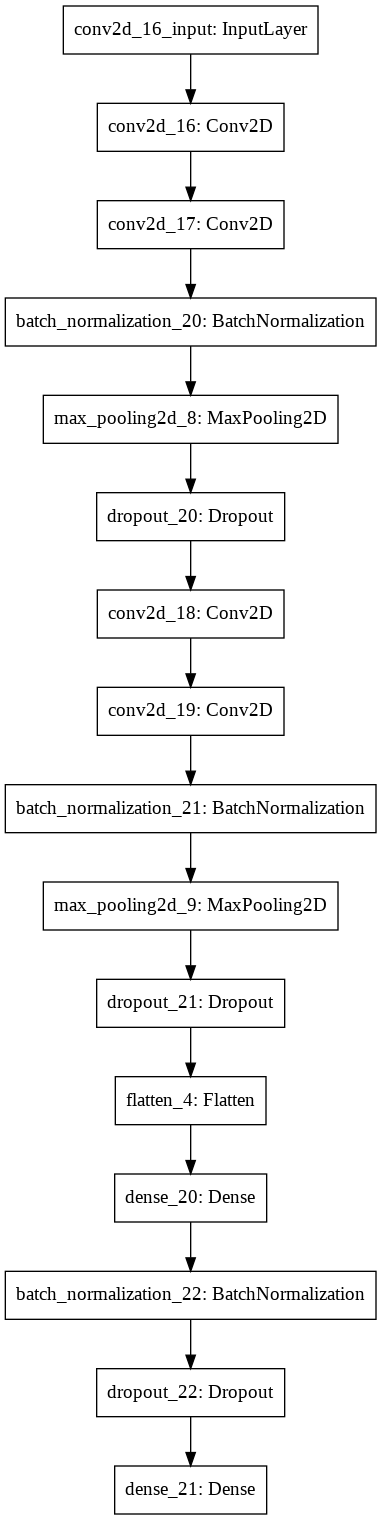

In [ ]:
# Specify parameters for model (change as needed)
W, H = 28, 28 # image shape
nClasses = 10 # number of classes
K1, K2, K3, K4, n = 16, 32, 64, 128, 256
dropOutRate = 0.2
kernel_size = (3,3) 
pool_size = (2,2)

# Specify parameters for training (change as needed)
epochs = 20 # number of training epochs
batch_size = 256 # batch_size for training 

print("1. Number of convolution layers: %d" %len([K1, K2, K3, K4]))
print("2. Number of filters in the convolution layers:", tuple([K1, K2, K3, K4]))
print("3. Width (and height) of filters F = ", kernel_size[0])
print("4. Number of dense layers following the convolution layer (excluding the output layer) = %d" %len([n]))
print("5. Dense layer sizes:", n)
print("6. Dropout rate used = %4.2f" %dropout_rate)
print("7. Number of training epochs = %d" %epochs)
print("8. Batch size used = %d" %batch_size)

# create model
cnn = cnn4(W, H, nClasses,K1, K2, K3, K4, n, dropOutRate, kernel_size, pool_size)
print("9. Model summary:")
print(cnn.summary())
print("Plot model:")
plot_model(cnn, to_file='cnn.png') # save and display architecture

How many trainable weights (including bias weights) does your model contain? 

We shall compute it from the model summary by only taking into account the parameters associated with convolution layers and dense layers.

In [ ]:
n_wts = 160 + 4640 + 18496 + 73856 + 524544 + 2570 # change as needed based on your model
print("10.	Model contains %d trainable weights" %n_wts)

10.	Model contains 624266 trainable weights


Train model

Epoch 1/20
211/211 [==============================] - 3s 14ms/step - loss: 0.2061 - accuracy: 0.9361 - val_loss: 3.1026 - val_accuracy: 0.2940
Epoch 2/20
211/211 [==============================] - 3s 13ms/step - loss: 0.0636 - accuracy: 0.9809 - val_loss: 0.7082 - val_accuracy: 0.7655
Epoch 3/20
211/211 [==============================] - 3s 13ms/step - loss: 0.0470 - accuracy: 0.9852 - val_loss: 0.0406 - val_accuracy: 0.9893
Epoch 4/20
211/211 [==============================] - 3s 13ms/step - loss: 0.0383 - accuracy: 0.9876 - val_loss: 0.0291 - val_accuracy: 0.9908
Epoch 5/20
211/211 [==============================] - 3s 12ms/step - loss: 0.0333 - accuracy: 0.9896 - val_loss: 0.0270 - val_accuracy: 0.9925
Epoch 6/20
211/211 [==============================] - 3s 12ms/step - loss: 0.0291 - accuracy: 0.9911 - val_loss: 0.0285 - val_accuracy: 0.9915
Epoch 7/20
211/211 [==============================] - 3s 12ms/step - loss: 0.0252 - accuracy: 0.9924 - val_loss: 0.0267 - val_accuracy: 0.9920

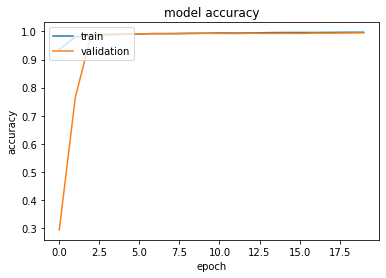

In [ ]:
history = cnn.fit(Xform_cnn(x_train), to_categorical(y_train),
                    epochs=epochs, batch_size=batch_size, validation_split=0.1)

# plot history
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

Evaluate trained cnn

In [ ]:
pred_cnn = cnn.predict(Xform_cnn(x_test)).argmax(axis=1) # predicted classes
acc_cnn = accuracy_score(y_test, pred_cnn) # accuracy

print("11.	Accuracy for the 10,000 test examples = %4.4f" %acc_cnn)

print("12.	Classification report for the 10,000 test examples:")
print(classification_report(y_test, pred_cnn, digits=4))

print("13.	Confusion matrix for the 10,000 test examples::")
cm_cnn = pd.DataFrame(confusion_matrix(y_test, pred_cnn))
cm_cnn.to_csv("confusion_matrix_cnn.csv") # save confusion_matrix
cm_cnn # display confusion_matrix

11.	Accuracy for the 10,000 test examples = 0.9948
12.	Classification report for the 10,000 test examples:
              precision    recall  f1-score   support

           0     0.9919    0.9980    0.9949       980
           1     0.9974    1.0000    0.9987      1135
           2     0.9971    0.9942    0.9956      1032
           3     0.9970    0.9950    0.9960      1010
           4     0.9939    0.9949    0.9944       982
           5     0.9922    0.9933    0.9927       892
           6     0.9979    0.9906    0.9942       958
           7     0.9884    0.9971    0.9927      1028
           8     0.9979    0.9949    0.9964       974
           9     0.9940    0.9891    0.9916      1009

    accuracy                         0.9948     10000
   macro avg     0.9948    0.9947    0.9947     10000
weighted avg     0.9948    0.9948    0.9948     10000

13.	Confusion matrix for the 10,000 test examples::


,0,1,2,3,4,5,6,7,8,9
0,978,0,0,0,0,0,1,1,0,0
1,0,1135,0,0,0,0,0,0,0,0
2,1,0,1026,0,0,0,0,5,0,0
3,0,0,1,1005,0,3,0,0,1,0
4,0,0,0,0,977,0,0,1,0,4
5,1,0,0,3,0,886,1,1,0,0
6,4,1,0,0,1,2,949,0,1,0
7,0,2,0,0,0,0,0,1025,0,1
8,2,0,2,0,0,0,0,0,969,1
9,0,0,0,0,5,2,0,4,0,998


## Task 3. Predidict digit for unlabeled examples

In [ ]:
# predict using cnn
pred_new = cnn.predict(Xform_cnn(x_unlabeled)).argmax(axis=1) # predicted classes
pred_new # show predictions 

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8,
       8, 8, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9])

We shall display the unlabeled examples with predicted labels

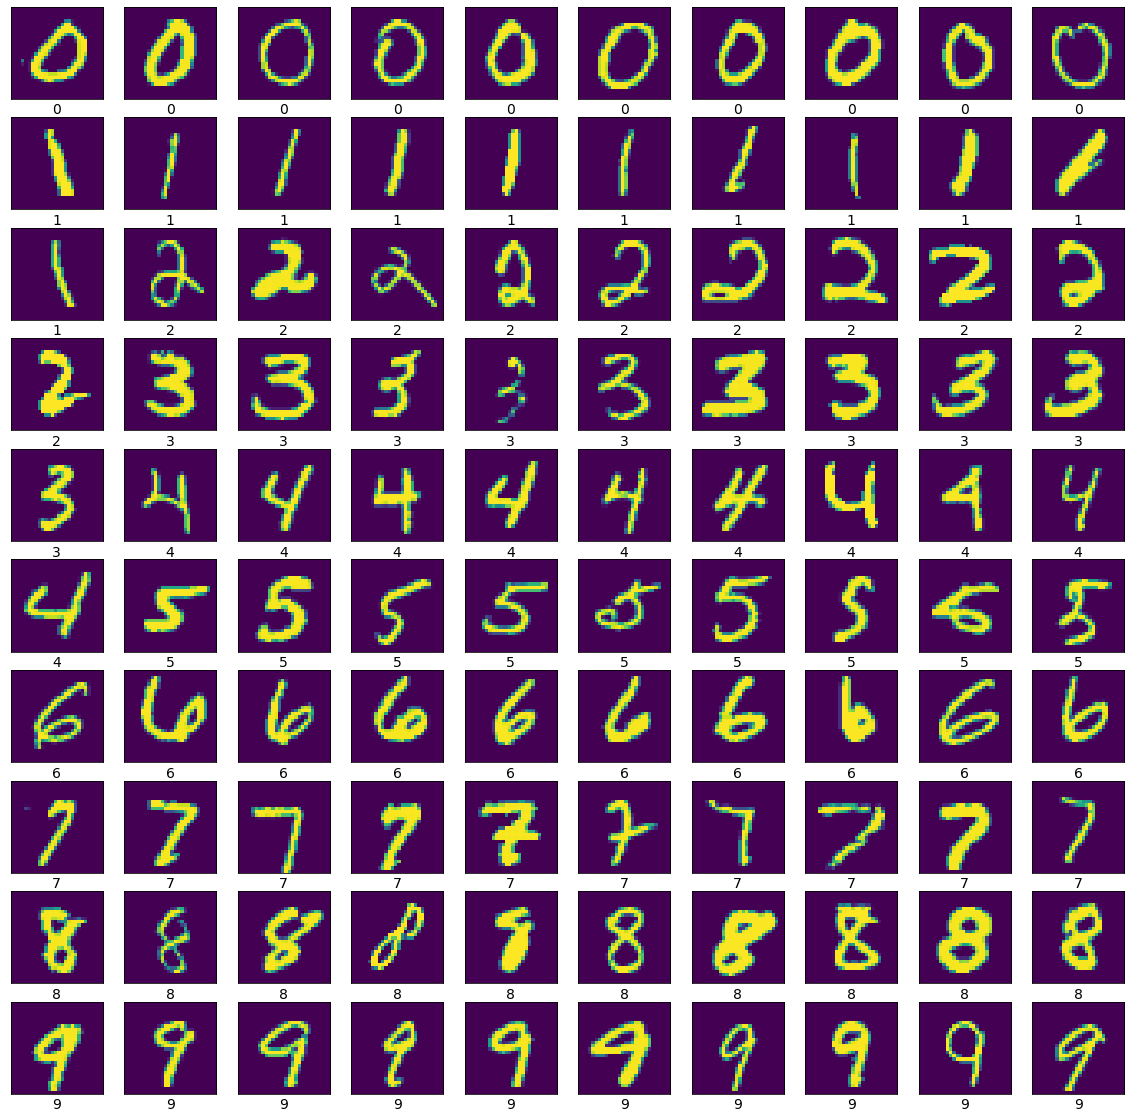

In [ ]:
def displayDigits(images, labels, nCols=10):
    """Displays images with labels (nCols per row)
    - images: list of vectors with 784 (28x28) grayscale values
    - labels: list of labels for images"""
    nRows = np.ceil(len(labels)/nCols).astype('int') # number of rows
    plt.figure(figsize=(2*nCols,2*nRows)) # figure size
    for i in range(len(labels)):
        plt.subplot(nRows,nCols,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i], interpolation='nearest')
        plt.xlabel(str(labels[i]), fontsize=14)
    plt.show()
    return

displayDigits(x_unlabeled, pred_new, nCols=10)